# EDA automatizado para Pharma Sales

Este notebook carga el dataframe actual desde `copilot-instructions.md`, clasifica variables, realiza un análisis estadístico inicial y genera los primeros gráficos con seaborn.

In [3]:
import re
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

root = Path('..').resolve() / 'Pharma Sales' if Path.cwd().name != 'Pharma Sales' else Path.cwd()
instructions_path = Path('c:/Users/sergi/Desktop/DATA/CURSO DS4B/EstructuraDirectorio/Pharma Sales/copilot-instructions.md')

with instructions_path.open('r', encoding='utf-8') as f:
    text = f.read()
match = re.search(r'\*\*Dataframe actual\*\*: `([^`]+)`', text)
if match is None:
    raise ValueError('No se pudo extraer la ruta del dataframe actual de copilot-instructions.md')
raw_path = Path(match.group(1))
candidate = instructions_path.parent / raw_path
if not candidate.exists():
    fallback_candidate = instructions_path.parent / Path(*raw_path.parts[1:]) if raw_path.parts and raw_path.parts[0] == '..' else candidate
    if fallback_candidate.exists():
        dataframe_path = fallback_candidate
    else:
        raise FileNotFoundError(f'No se encontró el dataframe en ninguna ruta esperada: {candidate} o {fallback_candidate}')
else:
    dataframe_path = candidate

print('Ruta extraída del dataframe actual:', dataframe_path)
df = pd.read_pickle(dataframe_path)
print('Dataframe cargado con éxito')
print(df.shape)
df.head()

Ruta extraída del dataframe actual: c:\Users\sergi\Desktop\DATA\CURSO DS4B\EstructuraDirectorio\Pharma Sales\02_datos\03_Entrenamiento\02_train_tablon_calidad.pkl
Dataframe cargado con éxito
(51249, 15)


,datum,m01ab,m01ae,n02ba,n02be,n05b,n05c,r03,r06,year,month,hour,weekday_name,granularity,date
0,1/2/2014,0.0,3.67,3.4,32.4,7.0,0.0,0.0,2.0,2014,1,<NA>,Thursday,day,2014-01-02 00:00:00
1,1/2/2014 8:00,0.0,0.67,0.4,2.0,0.0,0.0,0.0,1.0,2014,1,8,Thursday,hour,2014-01-02 08:00:00
2,1/2/2014 9:00,0.0,0.00,1.0,0.0,2.0,0.0,0.0,0.0,2014,1,9,Thursday,hour,2014-01-02 09:00:00
3,1/2/2014 10:00,0.0,0.00,0.0,3.0,2.0,0.0,0.0,0.0,2014,1,10,Thursday,hour,2014-01-02 10:00:00
4,1/2/2014 11:00,0.0,0.00,0.0,2.0,1.0,0.0,0.0,0.0,2014,1,11,Thursday,hour,2014-01-02 11:00:00


In [4]:
sns.set_theme(style='ticks', rc={'axes.spines.right': False, 'axes.spines.top': False})
print('Seaborn theme configurado')

Seaborn theme configurado


In [5]:
def summarize_variable_types(df):
    n_rows = len(df)
    numeric = df.select_dtypes(include=['number'])
    object_cols = df.select_dtypes(include=['object', 'category'])
    datetime_cols = df.select_dtypes(include=['datetime', 'datetime64[ns]'])
    discrete = []
    continuous = []
    for col in numeric.columns:
        unique_count = df[col].nunique(dropna=True)
        if pd.api.types.is_integer_dtype(df[col]) or pd.api.types.is_bool_dtype(df[col]):
            if unique_count <= min(20, 0.05 * n_rows):
                discrete.append(col)
            else:
                continuous.append(col)
        else:
            continuous.append(col)
    categorical = list(object_cols.columns)
    boolean = [col for col in object_cols.columns if df[col].dropna().isin([0,1,'0','1',True,False]).all()]
    text = [col for col in object_cols.columns if df[col].nunique(dropna=False) > 50 and df[col].astype(str).str.len().median() > 10]
    high_cardinality = [col for col in categorical if df[col].nunique(dropna=True) > 50]
    return {
        'num_discrete': discrete,
        'num_continuous': continuous,
        'categorical': categorical,
        'boolean': boolean,
        'high_cardinality': high_cardinality,
        'text': text,
        'datetime': list(datetime_cols.columns)
    }

types = summarize_variable_types(df)
print('Tipo de variables detectado:')
for k,v in types.items():
    print(f'{k}: {len(v)} columnas -> {v}')

Tipo de variables detectado:
num_discrete: 2 columnas -> ['year', 'month']
num_continuous: 9 columnas -> ['m01ab', 'm01ae', 'n02ba', 'n02be', 'n05b', 'n05c', 'r03', 'r06', 'hour']
categorical: 3 columnas -> ['datum', 'weekday_name', 'granularity']
boolean: 0 columnas -> []
high_cardinality: 1 columnas -> ['datum']
text: 1 columnas -> ['datum']
datetime: 1 columnas -> ['date']


## Resumen inicial de calidad y estructura

In [6]:
# Resumen de calidad de datos
missing = df.isna().mean() * 100
const_cols = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]
cardinality = df.nunique(dropna=False).sort_values()
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_pct': missing,
    'cardinality': cardinality,
    'constant': [col in const_cols for col in df.columns]
}, index=df.columns)
print('Filas, columnas:', df.shape)
print('Columnas constantes:', const_cols)
print('Columnas con más de 20% missing:')
print(summary[summary['missing_pct'] > 20][['dtype','missing_pct','cardinality']])
summary

Filas, columnas: (51249, 15)
Columnas constantes: []
Columnas con más de 20% missing:
Empty DataFrame
Columns: [dtype, missing_pct, cardinality]
Index: []


,dtype,missing_pct,cardinality,constant
datum,object,0.000000,50958,False
m01ab,float64,0.000000,571,False
m01ae,float64,0.000000,1210,False
n02ba,float64,0.000000,517,False
n02be,float64,0.000000,1331,False
n05b,float64,0.000000,261,False
n05c,float64,0.000000,51,False
r03,float64,0.000000,180,False
r06,float64,0.000000,303,False
year,Int64,0.000000,6,False


In [7]:
# Estadísticas extendidas para variables numéricas
num_cols = types['num_discrete'] + types['num_continuous']
stats = df[num_cols].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).T
stats['missing_pct'] = missing[num_cols]
stats['skew'] = df[num_cols].skew()
stats['kurtosis'] = df[num_cols].kurtosis()

# Detección de outliers por IQR
outliers = {}
for col in num_cols:
    series = df[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers[col] = {
        'iqr': iqr,
        'lower': lower,
        'upper': upper,
        'outlier_count': int(((series < lower) | (series > upper)).sum()),
        'outlier_pct': float(((series < lower) | (series > upper)).mean() * 100)
    }
outliers_df = pd.DataFrame(outliers).T
print('Estadísticas extendidas para variables numéricas')
stats[['count','mean','std','min','1%','5%','25%','50%','75%','95%','99%','max','missing_pct','skew','kurtosis']]

Estadísticas extendidas para variables numéricas


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct,skew,kurtosis
year,51249.0,2016.312201,1.620407,2014.0,2014.0,2014.0,2015.0,2016.0,2018.0,2019.0,2019.0,2019.0,0.000000,0.073705,-1.180557
month,51249.0,6.266034,3.413706,1.0,1.0,1.0,3.0,6.0,9.0,12.0,12.0,12.0,0.000000,0.100108,-1.165093
m01ab,51249.0,0.7913,6.214665,0.0,0.0,0.0,0.0,0.0,0.0,2.33,9.0,211.13,0.000000,20.912207,517.371997
m01ae,51249.0,0.618534,4.90677,0.0,0.0,0.0,0.0,0.0,0.0,2.0,7.02,222.351,0.000000,21.650887,572.814942
n02ba,51249.0,0.617942,4.918761,0.0,0.0,0.0,0.0,0.0,0.0,2.0,7.4,191.6,0.000000,21.581673,563.605133
n02be,51249.0,4.752209,39.008983,0.0,0.0,0.0,0.0,0.0,2.0,12.0,54.2,1856.815,0.000000,24.260437,745.970978
n05b,51249.0,1.400978,11.327442,0.0,0.0,0.0,0.0,0.0,0.0,4.0,17.84,492.0,0.000000,22.934956,664.540495
n05c,51249.0,0.093248,0.868415,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,50.0,0.000000,22.129339,711.035475
r03,51249.0,0.880982,7.833208,0.0,0.0,0.0,0.0,0.0,0.0,4.0,17.0,386.0,0.000000,24.685276,807.687263
r06,51249.0,0.456624,4.004944,0.0,0.0,0.0,0.0,0.0,0.0,1.3,6.404,213.04,0.000000,26.93161,951.374515


In [9]:
# Resumen para variables categóricas, booleanas y alta cardinalidad
cat_cols = types['categorical']
high_card = types['high_cardinality']
cat_summary = []
for col in cat_cols:
    series = df[col]
    counts = series.value_counts(dropna=False)
    top = counts.iloc[0]
    cat_summary.append({
        'column': col,
        'dtype': str(series.dtype),
        'missing_pct': float(series.isna().mean() * 100),
        'cardinality': int(series.nunique(dropna=True)),
        'top_category': counts.index[0],
        'top_category_pct': float(top / len(series) * 100),
        'high_cardinality': col in high_card,
        'rare_labels_count': int(((counts / len(series) * 100) < 1).sum())
    })
cat_report = pd.DataFrame(cat_summary).set_index('column')
print('Resumen categórico:')
cat_report

Resumen categórico:


,dtype,missing_pct,cardinality,top_category,top_category_pct,high_cardinality,rare_labels_count
column,,,,,,,
datum,object,0.0,50958,5/26/2019,0.003903,True,50958
weekday_name,object,0.0,7,Sunday,14.782727,False,0
granularity,object,0.0,4,hour,95.330641,False,2


## Análisis de fechas

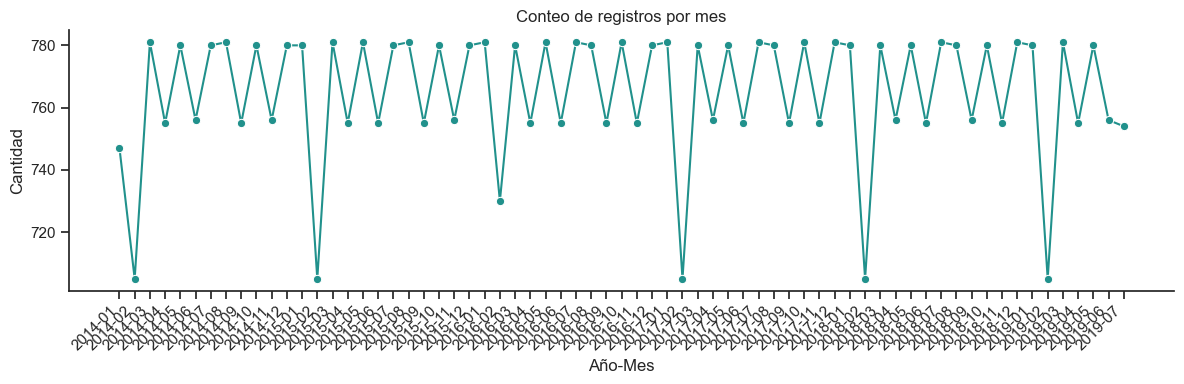


Guardando dataframe EDA en ../02_datos/03_Entrenamiento/03_train_tablon_eda.pkl

Estructura de df:
<class 'pandas.core.frame.DataFrame'>
Index: 51249 entries, 0 to 51248
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datum         51249 non-null  object        
 1   m01ab         51249 non-null  float64       
 2   m01ae         51249 non-null  float64       
 3   n02ba         51249 non-null  float64       
 4   n02be         51249 non-null  float64       
 5   n05b          51249 non-null  float64       
 6   n05c          51249 non-null  float64       
 7   r03           51249 non-null  float64       
 8   r06           51249 non-null  float64       
 9   year          51249 non-null  Int64         
 10  month         51249 non-null  Int64         
 11  hour          48856 non-null  Int64         
 12  weekday_name  51249 non-null  object        
 13  granularity   51249 non-null  object     

In [16]:
# Conteos por día y por mes en la columna date
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['year_month'] = df['date'].dt.to_period('M').astype(str)
    counts = df['year_month'].value_counts().sort_index()
    plt.figure(figsize=(12, 4))
    ax = sns.lineplot(x=counts.index, y=counts.values, marker='o', color=sns.color_palette('viridis', 1)[0])
    ax.set_title('Conteo de registros por mes')
    ax.set_xlabel('Año-Mes')
    ax.set_ylabel('Cantidad')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No hay columna date para analizar.')

# Guardar la versión EDA del dataframe y mostrar df.info()
print('\nGuardando dataframe EDA en ../02_datos/03_Entrenamiento/03_train_tablon_eda.pkl')
df.to_pickle('../02_datos/03_Entrenamiento/03_train_tablon_eda.pkl')
print('\nEstructura de df:')
df.info()  # La salida se capturará en el notebook para actualizar copilot-instructions.md

## Frecuencia de pedidos por día, semana y año

Aquí se cuenta cuántas veces cada producto registra demanda positiva en cada unidad temporal.

In [17]:
product_cols = [col for col in ['m01ab', 'm01ae', 'n02ba', 'n02be', 'n05b', 'n05c', 'r03', 'r06'] if col in df.columns]

# Función auxiliar para contar solicitudes positivas por periodo

def count_positive_by_period(df, product_cols, period_series):
    return (
        df.assign(period=period_series)
          .groupby('period')[product_cols]
          .agg(lambda s: int((s > 0).sum()))
          .sort_index()
    )

# Agregación por día, semana y año
period_daily = df['date'].dt.strftime('%Y-%m-%d')
period_weekly = df['date'].dt.to_period('W-MON').astype(str)
period_yearly = df['date'].dt.year

daily_counts = count_positive_by_period(df, product_cols, period_daily)
weekly_counts = count_positive_by_period(df, product_cols, period_weekly)
yearly_counts = count_positive_by_period(df, product_cols, period_yearly)

print('Resumen de frecuencia de pedidos por producto')
summary_counts = pd.DataFrame({
    'por_dia': daily_counts.sum().sort_values(ascending=False),
    'por_semana': weekly_counts.sum().sort_values(ascending=False),
    'por_anio': yearly_counts.sum().sort_values(ascending=False)
})
summary_counts

Resumen de frecuencia de pedidos por producto


,por_dia,por_semana,por_anio
n02be,22120,22120,22120
n05b,12574,12574,12574
m01ae,11558,11558,11558
m01ab,10930,10930,10930
n02ba,9567,9567,9567
r06,7239,7239,7239
r03,5218,5218,5218
n05c,1805,1805,1805


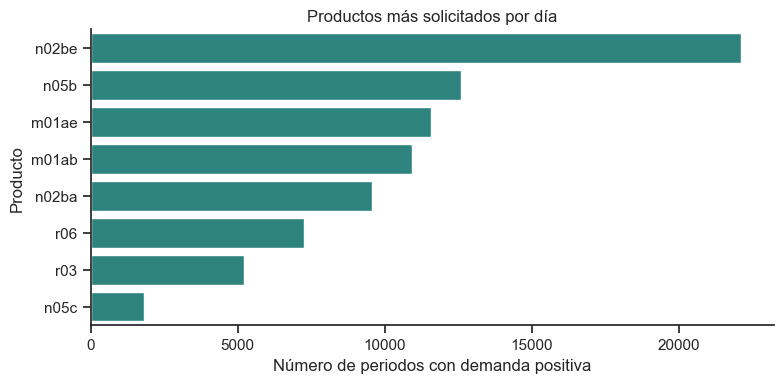

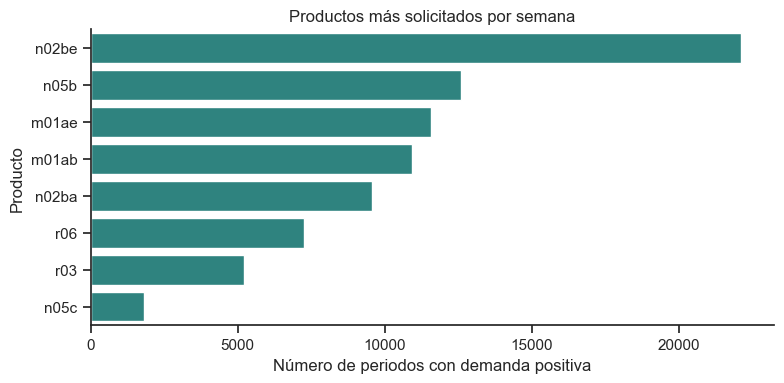

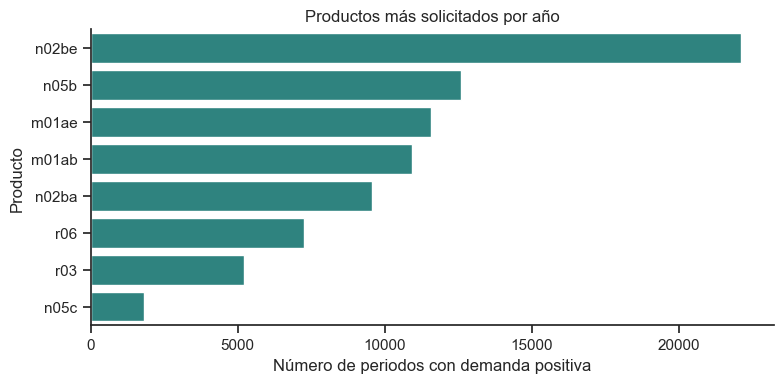

In [18]:
# Gráficos para los productos más solicitados por periodo
for label, counts in [('día', daily_counts.sum()), ('semana', weekly_counts.sum()), ('año', yearly_counts.sum())]:
    top = counts.sort_values(ascending=False).head(8)
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(x=top.values, y=top.index.astype(str), color=sns.color_palette('viridis', 1)[0])
    ax.set_title(f'Productos más solicitados por {label}')
    ax.set_xlabel('Número de periodos con demanda positiva')
    ax.set_ylabel('Producto')
    plt.tight_layout()
    plt.show()

## Análisis de Ventas Promedio y Estacionalidad

A continuación se realiza el análisis solicitado para visualizar las ventas promedio de cada tipo de medicamento por día, semana y mes, así como el estudio detallado de la estacionalidad (mensual, semanal dentro del mes, y día de la semana).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definición de columnas de productos y nombres legibles
product_cols = ['m01ab', 'm01ae', 'n02ba', 'n02be', 'n05b', 'n05c', 'r03', 'r06']
product_names = {
    'm01ab': 'M01AB (Antiinflamatorios)',
    'm01ae': 'M01AE (Antiinflamatorios/Reum.)',
    'n02ba': 'N02BA (Analgésicos/Antipirét.)',
    'n02be': 'N02BE (Analgésicos/Antipirét. Parac.)',
    'n05b': 'N05B (Psicolépticos/Ansiolíticos)',
    'n05c': 'N05C (Psicolépticos/Hipnóticos)',
    'r03': 'R03 (Asma/EPOC)',
    'r06': 'R06 (Antihistamínicos)'
}

# 2. Resumen de ventas promedio por granularidad
summary_data = []
for gran in ['day', 'week', 'month']:
    sub = df[df['granularity'] == gran]
    means = sub[product_cols].mean().to_dict()
    means['granularity'] = gran
    summary_data.append(means)
summary_df = pd.DataFrame(summary_data).set_index('granularity')

print("--- VENTAS PROMEDIO (DE MEDIA) POR GRANULARIDAD ---")
display(summary_df.rename(columns=product_names))

# Gráfico de Ventas Medias por Granularidad
melted_df = summary_df.reset_index().melt(id_vars='granularity', value_vars=product_cols, var_name='Producto', value_name='Venta_Media')
melted_df['Producto_Nombre'] = melted_df['Producto'].map(product_names)

fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=False)
granularities = ['day', 'week', 'month']
titles = ['Ventas Promedio Diarias por Producto', 'Ventas Promedio Semanales por Producto', 'Ventas Promedio Mensuales por Producto']

for i, (gran, title) in enumerate(zip(granularities, titles)):
    data_sub = melted_df[melted_df['granularity'] == gran].sort_values(by='Venta_Media', ascending=False)
    sns.barplot(
        x='Venta_Media', 
        y='Producto_Nombre', 
        data=data_sub, 
        ax=axes[i], 
        palette="viridis",
        hue='Producto_Nombre',
        legend=False
    )
    axes[i].set_title(title, fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel('Unidades Vendidas (Media)', fontsize=12)
    axes[i].set_ylabel('', fontsize=12)
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.2f', padding=5, fontsize=10)

plt.tight_layout()
plt.show()

# 3. Filtrar datos diarios para el análisis de estacionalidad
df_day = df[df['granularity'] == 'day'].copy()
df_day['date'] = pd.to_datetime(df_day['date'])

# A. Estacionalidad Mensual
monthly_avg = df_day.groupby('month')[product_cols].mean()
monthly_avg_named = monthly_avg.rename(columns=product_names)

plt.figure(figsize=(12, 6))
for col in monthly_avg_named.columns:
    plt.plot(monthly_avg_named.index, monthly_avg_named[col], marker='o', linewidth=2, label=col)
plt.title('Estacionalidad Mensual: Ventas Promedio Diarias por Mes', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ventas Promedio Diarias', fontsize=12)
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# B. Estacionalidad dentro del Mes (Semana del Mes)
df_day['week_of_month'] = (df_day['date'].dt.day - 1) // 7 + 1
wom_avg = df_day.groupby('week_of_month')[product_cols].mean()
wom_avg_named = wom_avg.rename(columns=product_names)

plt.figure(figsize=(12, 6))
for col in wom_avg_named.columns:
    plt.plot(wom_avg_named.index, wom_avg_named[col], marker='s', linewidth=2, label=col)
plt.title('Estacionalidad dentro del Mes: Ventas Promedio Diarias por Semana del Mes', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Semana del Mes (1 a 5)', fontsize=12)
plt.ylabel('Ventas Promedio Diarias', fontsize=12)
plt.xticks(range(1, 6), ['Semana 1 (Días 1-7)', 'Semana 2 (Días 8-14)', 'Semana 3 (Días 15-21)', 'Semana 4 (Días 22-28)', 'Semana 5 (Días 29+)'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# C. Estacionalidad dentro de la Semana (Día de la Semana)
df_day['dayofweek'] = df_day['date'].dt.dayofweek
dow_avg = df_day.groupby('dayofweek')[product_cols].mean()
dow_avg_named = dow_avg.rename(columns=product_names)
days_es = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

plt.figure(figsize=(12, 6))
for col in dow_avg_named.columns:
    plt.plot(dow_avg_named.index, dow_avg_named[col], marker='^', linewidth=2, label=col)
plt.title('Estacionalidad Semanal: Ventas Promedio Diarias por Día de la Semana', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Día de la Semana', fontsize=12)
plt.ylabel('Ventas Promedio Diarias', fontsize=12)
plt.xticks(range(7), days_es)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
